<a href="https://colab.research.google.com/github/Nikhitha-Vineeth/GIT-NIK/blob/master/tryingosmnx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<Axes: >

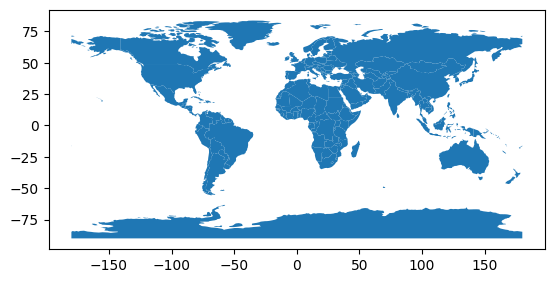

In [1]:
import geopandas as gpd

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)

world.plot()


In [3]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 2.1 MB/s eta 0:00:00


<Axes: >

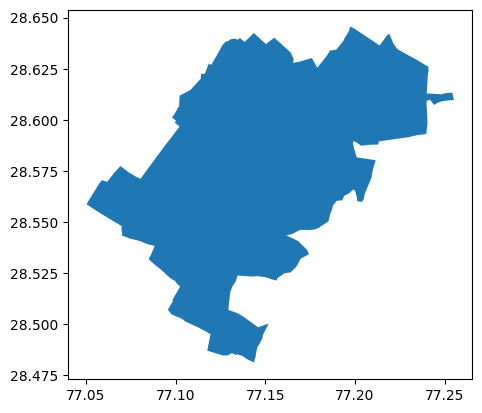

In [4]:

import osmnx as ox

gdf = ox.geocode_to_gdf("Delhi, India")

gdf.plot()


In [5]:
# View first rows
print(gdf.head())

# CRS (coordinate system)
print(gdf.crs)

# Geometry type
print(gdf.geometry.type)

# Columns
print(gdf.columns)

                                            geometry  bbox_west  bbox_south  \
0  POLYGON ((77.05037 28.55871, 77.05275 28.55734...  77.050371   28.481221   

   bbox_east  bbox_north   place_id  osm_type   osm_id        lat        lon  \
0  77.255139   28.645684  421003030  relation  2763541  28.613895  77.209006   

      class            type  place_rank  importance addresstype       name  \
0  boundary  administrative           9    0.702638        city  New Delhi   

              display_name  
0  New Delhi, Delhi, India  
epsg:4326
0    Polygon
dtype: object
Index(['geometry', 'bbox_west', 'bbox_south', 'bbox_east', 'bbox_north',
       'place_id', 'osm_type', 'osm_id', 'lat', 'lon', 'class', 'type',
       'place_rank', 'importance', 'addresstype', 'name', 'display_name'],
      dtype='object')


In [6]:
# Project to UTM (meters)
gdf_proj = gdf.to_crs(epsg=32643)   # UTM zone for Delhi

# Area (in sq km)
gdf_proj["area_sqkm"] = gdf_proj.area / 1e6

# Perimeter (in km)
gdf_proj["perimeter_km"] = gdf_proj.length / 1000

print(gdf_proj[["area_sqkm", "perimeter_km"]])


    area_sqkm  perimeter_km
0  161.388665     79.403127


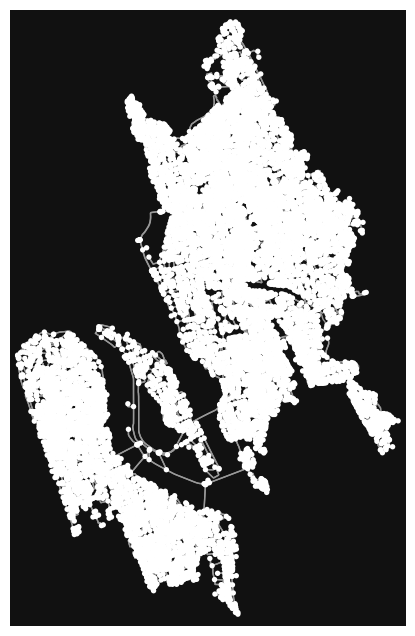

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [7]:
# Download road network
G = ox.graph_from_place("Kochi, India", network_type="drive")

# Plot roads
ox.plot_graph(G)


In [8]:
stats = ox.basic_stats(G)

for k, v in stats.items():
    print(k, ":", v)


n : 13570
m : 32813
k_avg : 4.836109064112012
edge_length_total : 2449284.030236839
edge_length_avg : 74.64370920783954
streets_per_node_avg : 2.490051584377303
streets_per_node_counts : {0: 0, 1: 3955, 2: 2, 3: 8634, 4: 968, 5: 9, 6: 2}
streets_per_node_proportions : {0: 0.0, 1: 0.291451731761238, 2: 0.00014738393515106854, 3: 0.6362564480471629, 4: 0.07133382461311717, 5: 0.0006632277081798084, 6: 0.00014738393515106854}
intersection_count : 9615
street_length_total : 1272310.235820477
street_segment_count : 16866
street_length_avg : 75.4363948666238
circuity_avg : 1.059516868293804
self_loop_proportion : 0.0005929088106249259


Number of buildings: 25266


<Axes: >

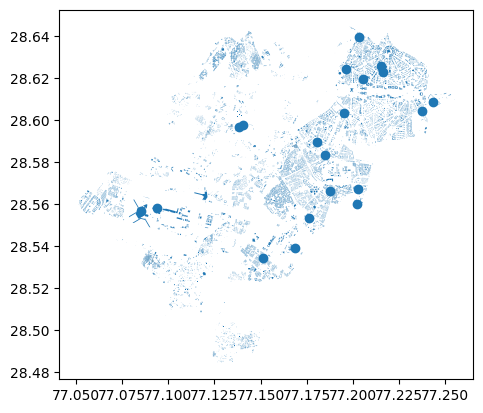

In [9]:
from shapely.geometry import Polygon

# Get polygon
polygon = gdf.geometry.iloc[0]

# Download buildings
buildings = ox.features_from_polygon(
    polygon,
    tags={"building": True}
)

print("Number of buildings:", len(buildings))

buildings.plot()


In [10]:
area = gdf_proj["area_sqkm"].iloc[0]

density = len(buildings) / area

print("Building Density per sq km:", density)


Building Density per sq km: 156.55374561255599


/tmp/ipython-input-2875574209.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings["centroid"] = buildings.centroid


<Axes: >

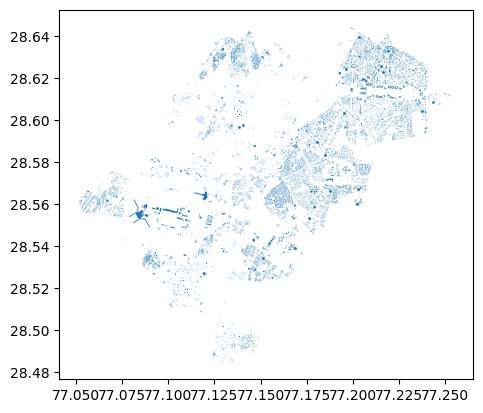

In [11]:
# Count buildings per ward (if available)
buildings["centroid"] = buildings.centroid

buildings.plot(markersize=1)


In [12]:
landuse = ox.features_from_polygon(
    polygon,
    tags={"landuse": True}
)

landuse["landuse"].value_counts()


,count
landuse,
grass,559
residential,318
commercial,134
military,89
institutional,57
construction,45
retail,39
industrial,21
education,13


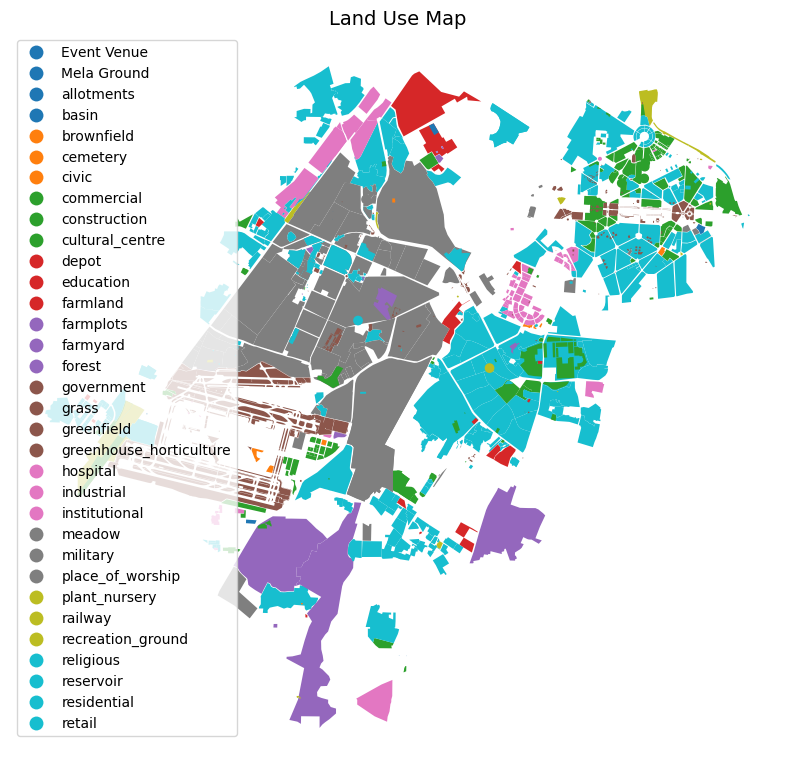

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

landuse.plot(
    column="landuse",
    categorical=True,
    legend=True,
    ax=ax
)

ax.set_title("Land Use Map", fontsize=14)
ax.axis("off")

plt.show()


<Axes: >

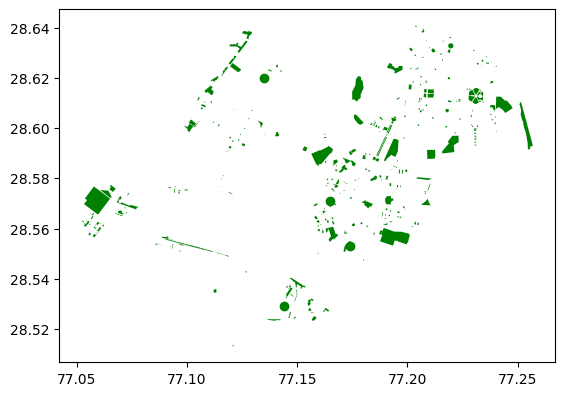

In [13]:
green = ox.features_from_polygon(
    polygon,
    tags={"leisure": "park"}
)

green.plot(color="green")


In [14]:
print("Number of parks:", len(green))


Number of parks: 393


In [15]:
# Convert geometry to centroids
buildings["centroid"] = buildings.geometry.centroid

# Extract lat/lon
buildings["lat"] = buildings.centroid.y
buildings["lon"] = buildings.centroid.x


/tmp/ipython-input-77285652.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings["centroid"] = buildings.geometry.centroid
/tmp/ipython-input-77285652.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings["lat"] = buildings.centroid.y
/tmp/ipython-input-77285652.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings["lon"] = buildings.centroid.x


In [16]:
buildings_tabular = buildings.drop(columns=["geometry", "centroid"])



In [17]:

buildings_tabular.to_excel("delhi_buildings.xlsx", index=False)


In [18]:
from google.colab import files
files.download("delhi_buildings.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

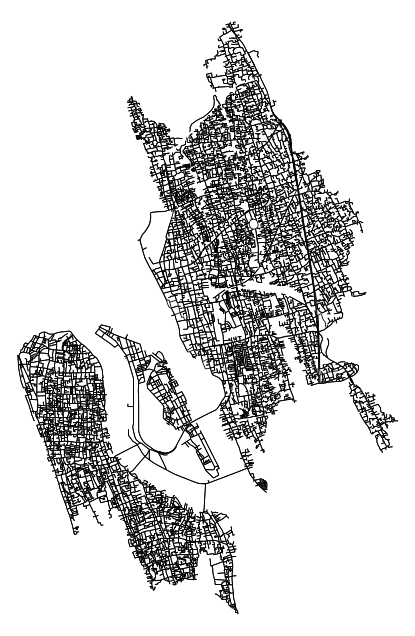

In [19]:
import osmnx as ox
import matplotlib.pyplot as plt

# Define the place
place_name = "Kochi, India"

# Download road network (drive = motorable roads)
G = ox.graph_from_place(place_name, network_type="drive")

# Plot the road network
fig, ax = ox.plot_graph(
    G,
    bgcolor="white",
    node_size=0,
    edge_color="black",
    edge_linewidth=0.6
)

plt.show()


In [22]:
!pip install contextily

--- Analysis for Kochi, India ---
Total Area: 99.38 sq km
Building Density: 484.30 buildings/sq km


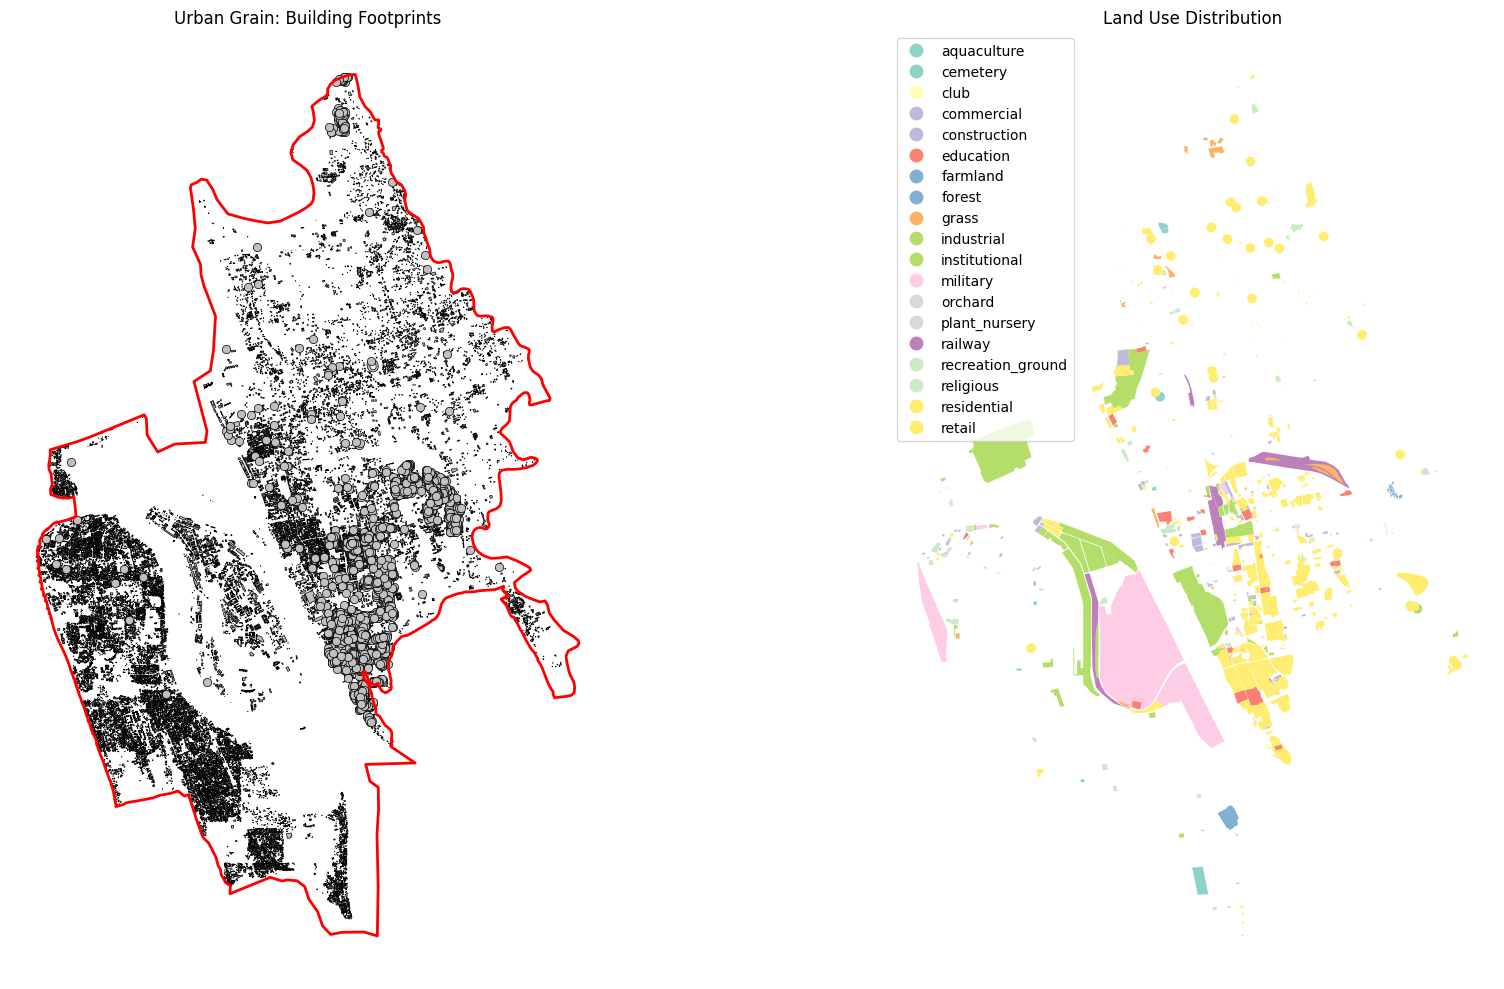

In [24]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# Install osmnx to ensure it's available in the current environment


# 1. Define Area of Interest (AOI)
place_name = "Kochi, India"
gdf = ox.geocode_to_gdf(place_name)

# 2. Project to a local UTM zone for accurate area calculations (meters/sq km)
# .get_utm_crs() automatically finds the right projection
gdf_proj = gdf.to_crs(gdf.estimate_utm_crs())
area_sqkm = gdf_proj.geometry.area.iloc[0] / 10**6

# 3. Fetch Data
# Fetch buildings
buildings = ox.features_from_polygon(gdf.geometry.iloc[0], tags={"building": True})

# Fetch Land Use
landuse = ox.features_from_polygon(gdf.geometry.iloc[0], tags={"landuse": True})

# 4. Calculations
building_count = len(buildings)
density = building_count / area_sqkm

print(f"--- Analysis for {place_name} ---")
print(f"Total Area: {area_sqkm:.2f} sq km")
print(f"Building Density: {density:.2f} buildings/sq km")

# 5. Visualization
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Plot 1: Building Footprints
buildings.plot(ax=ax[0], color="silver", edgecolor="black", lw=0.5)
gdf.plot(ax=ax[0], facecolor="none", edgecolor="red", linewidth=2)
ax[0].set_title("Urban Grain: Building Footprints")

# Plot 2: Land Use Map
landuse.plot(column="landuse", ax=ax[1], legend=True, cmap="Set3")
ax[1].set_title("Land Use Distribution")

for a in ax:
    a.set_axis_off()

plt.tight_layout()
plt.show()